> **Note:** This notebook contains an inline prototype of the LexiLens SDK for educational purposes. The production client SDK is published separately at [github.com/curvsort/lexilensai-sdk](https://github.com/curvsort/lexilensai-sdk).
> 
> The open-source `agent-session-graph` library (this repo) provides the backend session reconstruction engine. The SDK handles instrumentation and data collection.

"Agents as Tools" is an architectural pattern in AI systems where specialized AI agents are wrapped as callable functions (tools) that can be used by other agents. This creates a hierarchical structure where:

1. A primary "orchestrator" agent handles user interaction and determines which specialized agent to call

2. Specialized "tool agents" perform domain-specific tasks when called by the orchestrator

This approach mimics human team dynamics, where a manager coordinates specialists, each bringing unique expertise to solve complex problems. Rather than a single agent trying to handle everything, tasks are delegated to the most appropriate specialized agent.

## Key Benefits and Core Principles

The "Agents as Tools" pattern offers several advantages:

- Separation of concerns: Each agent has a focused area of responsibility, making the system easier to understand and maintain
- Hierarchical delegation: The orchestrator decides which specialist to invoke, creating a clear chain of command
- Modular architecture: Specialists can be added, removed, or modified independently without affecting the entire system
- Improved performance: Each agent can have tailored system prompts and tools optimized for its specific task

In [1]:
import sys
print(sys.executable)

/Users/rbakshi/.pyenv/versions/3.12.2/bin/python3.12


In [2]:
!pip install -r requirements.txt


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [3]:
import strands
import boto3
import pydantic

print("All imports successful")

All imports successful


In [4]:
import os

from strands import Agent, tool
from strands_tools import file_write

---
# Part 1: Manual Instrumentation — The Observability Tax

In this section we instrument a multi-agent orchestrator workflow **by hand** using custom `emit_span()` calls. This is what most teams do today when they need visibility into agent behavior.

Pay attention to how much boilerplate this requires per tool.

In [5]:
import json
import uuid
from datetime import datetime
from pathlib import Path

TRACE_DIR = Path("./raw_traces/strands_manual")
TRACE_DIR.mkdir(parents=True, exist_ok=True)

TRACE_FILE = TRACE_DIR / "strands_runtime.jsonl"
GLOBAL_TRACE_ID = str(uuid.uuid4())


def emit_span(
    span_id,
    parent_span_id,
    agent,
    event,
    status="success",
    token_input=None,
    token_output=None,
    metadata=None
):
    span = {
        "trace_id": GLOBAL_TRACE_ID,
        "span_id": span_id,
        "parent_span_id": parent_span_id,
        "timestamp": datetime.utcnow().isoformat(),
        "agent": agent,
        "event": event,
        "status": status,
        "token_input": token_input,
        "token_output": token_output,
        "metadata": metadata or {}
    }
    with open(TRACE_FILE, "a") as f:
        f.write(json.dumps(span) + "\n")

In this module we will be creating an orchestrator based multi-agent workflow. 

<div style="text-align:left">
    <img src="images/architecture.png" width="75%" />
</div>

We will also explore `use_llm` which allows us to create nested agents.

## Research Agent

Let's first create a basic research assistant.

In [6]:
RESEARCH_ASSISTANT_PROMPT = """You are a specialized research assistant. Focus only on providing
factual, well-sourced information in response to research questions.
Always cite your sources when possible."""

In [7]:
research_agent = Agent(
    model="global.anthropic.claude-sonnet-4-5-20250929-v1:0",
    system_prompt=RESEARCH_ASSISTANT_PROMPT,
)

query = "Overview of Amazon Bedrock and its features"
response = research_agent(query)

# Amazon Bedrock Overview

Amazon Bedrock is a fully managed service from AWS that provides access to foundation models (FMs) from leading AI companies through a single API. Launched in **September 2023** for general availability, it enables organizations to build and scale generative AI applications.

## Key Features

### 1. **Multi-Model Access**
- Access to foundation models from multiple providers including:
  - **Anthropic** (Claude models)
  - **AI21 Labs** (Jurassic models)
  - **Cohere** (Command and Embed models)
  - **Meta** (Llama 2)
  - **Stability AI** (Stable Diffusion)
  - **Amazon Titan** (Amazon's own models)

### 2. **Model Customization**
- **Fine-tuning**: Customize models with your own labeled datasets
- **Continued pre-training**: Adapt models to specific domains with unlabeled data
- Customization without exposing underlying model weights

### 3. **Retrieval-Augmented Generation (RAG)**
- **Knowledge Bases**: Connect FMs to your proprietary data sources
- Integra

Now we can wrap this agent as a tool. Allowing other agents to interact with it. 

#### Best Practices for Agent as Tools

When implementing the "Agents as Tools" pattern with Strands Agents:

1. Clear tool documentation: Write descriptive docstrings that explain the agent's expertise
2. Focused system prompts: Keep each specialized agent tightly focused on its domain
3. Proper response handling: Use consistent patterns to extract and format responses
4. Tool selection guidance: Give the orchestrator clear criteria for when to use each specialized agent

In [8]:
@tool
def research_assistant(query: str) -> str:

    tool_span_id = str(uuid.uuid4())

    emit_span(
        span_id=tool_span_id,
        parent_span_id="orchestrator_root",
        agent="research_assistant_tool",
        event="tool_invoked",
        metadata={"query": query}
    )

    try:
        research_agent = Agent(
            model="global.anthropic.claude-sonnet-4-5-20250929-v1:0",
            system_prompt=RESEARCH_ASSISTANT_PROMPT,
        )

        child_span_id = str(uuid.uuid4())

        emit_span(
            span_id=child_span_id,
            parent_span_id=tool_span_id,
            agent="research_agent",
            event="agent_execution_started",
            metadata={"query": query}
        )

        response = research_agent(query)

        emit_span(
            span_id=child_span_id,
            parent_span_id=tool_span_id,
            agent="research_agent",
            event="agent_execution_completed",
            metadata={"response_size": len(str(response))}
        )

        return str(response)

    except Exception as e:
        emit_span(
            span_id=tool_span_id,
            parent_span_id="orchestrator_root",
            agent="research_assistant_tool",
            event="tool_failed",
            status="failed",
            metadata={"error": str(e)}
        )
        return f"Error in research assistant: {str(e)}"

Now let's follow the best practices and create `product_recommendation_assistant`, `trip_planning_assistant`, and `orchestrator` agent.

### Product Recommendation Assistant

In [9]:
@tool
def product_recommendation_assistant(query: str) -> str:

    tool_span_id = str(uuid.uuid4())

    emit_span(
        span_id=tool_span_id,
        parent_span_id="orchestrator_root",
        agent="product_recommendation_tool",
        event="tool_invoked",
        metadata={"query": query}
    )

    try:
        product_agent = Agent(
            model="global.anthropic.claude-sonnet-4-5-20250929-v1:0",
            system_prompt="""You are a specialized product recommendation assistant.
            Provide personalized product suggestions based on user preferences.
            Always cite your sources.""",
        )

        child_span_id = str(uuid.uuid4())

        emit_span(
            span_id=child_span_id,
            parent_span_id=tool_span_id,
            agent="product_agent",
            event="agent_execution_started",
            metadata={"query": query}
        )

        response = product_agent(query)

        emit_span(
            span_id=child_span_id,
            parent_span_id=tool_span_id,
            agent="product_agent",
            event="agent_execution_completed",
            metadata={"response_size": len(str(response))}
        )

        return str(response)

    except Exception as e:
        emit_span(
            span_id=tool_span_id,
            parent_span_id="orchestrator_root",
            agent="product_recommendation_tool",
            event="tool_failed",
            status="failed",
            metadata={"error": str(e)}
        )
        return f"Error in product recommendation: {str(e)}"

### Trip Planning Assistant

In [10]:
@tool
def trip_planning_assistant(query: str) -> str:

    tool_span_id = str(uuid.uuid4())

    emit_span(
        span_id=tool_span_id,
        parent_span_id="orchestrator_root",
        agent="trip_planning_tool",
        event="tool_invoked",
        metadata={"query": query}
    )

    try:
        travel_agent = Agent(
            model="global.anthropic.claude-sonnet-4-5-20250929-v1:0",
            system_prompt="""You are a specialized travel planning assistant.
            Create detailed travel itineraries based on user preferences.""",
        )

        child_span_id = str(uuid.uuid4())

        emit_span(
            span_id=child_span_id,
            parent_span_id=tool_span_id,
            agent="travel_agent",
            event="agent_execution_started",
            metadata={"query": query}
        )

        response = travel_agent(query)

        emit_span(
            span_id=child_span_id,
            parent_span_id=tool_span_id,
            agent="travel_agent",
            event="agent_execution_completed",
            metadata={"response_size": len(str(response))}
        )

        return str(response)

    except Exception as e:
        emit_span(
            span_id=tool_span_id,
            parent_span_id="orchestrator_root",
            agent="trip_planning_tool",
            event="tool_failed",
            status="failed",
            metadata={"error": str(e)}
        )
        return f"Error in trip planning: {str(e)}"

### Orchestrator Agent

In [11]:
# Define orchestrator system prompt with clear tool selection guidance
MAIN_SYSTEM_PROMPT = """
You are an assistant that routes queries to specialized agents:
- For research questions and factual information → Use the research_assistant tool
- For product recommendations and shopping advice → Use the product_recommendation_assistant tool
- For travel planning and itineraries → Use the trip_planning_assistant tool
- For simple questions not requiring specialized knowledge → Answer directly

Always select the most appropriate tool based on the user's query.
"""

In [12]:
# Strands Agents allows easy integration of agent tools
orchestrator = Agent(
    model="global.anthropic.claude-sonnet-4-5-20250929-v1:0",
    system_prompt=MAIN_SYSTEM_PROMPT,
    tools=[
        research_assistant,
        product_recommendation_assistant,
        trip_planning_assistant,
        file_write,
    ],
)

In [13]:
# Example: E-commerce Customer Service System
customer_query = (
    "I'm looking for hiking boots. Write the final response to current directory."
)

os.environ["BYPASS_TOOL_CONSENT"] = "true"

emit_span(
    span_id="orchestrator_root",
    parent_span_id=None,
    agent="orchestrator",
    event="workflow_started",
    metadata={"query": customer_query}
)

response = orchestrator(customer_query)

emit_span(
    span_id="orchestrator_root_end",
    parent_span_id="orchestrator_root",
    agent="orchestrator",
    event="workflow_completed"
)

/var/folders/84/0ydjkq3n6rg9j3wc_fl9y4gw0000gn/T/ipykernel_67712/4141765146.py:27: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat(),


I'll help you find hiking boots recommendations and save the information to a file.
Tool #1: product_recommendation_assistant
I'd be happy to help you find hiking boots! To give you the best recommendations, I need to know more about your specific needs:

## Key Questions:

1. **Terrain Type**: Where will you hike?
   - Day hikes on maintained trails
   - Backpacking with heavy loads
   - Rocky/technical terrain
   - Winter/snow conditions

2. **Budget Range**: What's your price point?
   - Budget-friendly ($80-150)
   - Mid-range ($150-250)
   - Premium ($250+)

3. **Foot Characteristics**:
   - Wide or narrow feet?
   - High or low arches?
   - Any ankle support concerns?

4. **Experience Level**: Beginner or experienced hiker?

## General Top Categories:

**For Day Hiking (Light trails)**:
- Mid-cut hiking shoes or low-cut trail shoes
- More flexible, lighter weight

**For Backpacking**:
- Full-height hiking boots
- Better ankle support and durability

**For Technical Terrain**:
- S

╔═════════ File Write Operation ═════════╗
║                                        ║
║ Path: hiking_boots_recommendations.txt ║
║ Size: 1159 characters                  ║
║                                        ║
╚════════════════════════════════════════╝

╔══════════════════════ Write Successful ═══════════════════════╗
║ File written successfully to hiking_boots_recommendations.txt ║
╚═══════════════════════════════════════════════════════════════╝

Perfect! I've gathered hiking boots recommendations and saved them to **hiking_boots_recommendations.txt** in your current directory.

The file contains guidance on choosing hiking boots based on:
- Terrain type you'll be hiking
- Your budget range
- Foot characteristics and support needs
- Experience level

To get more specific boot model recommendations, you can provide additional details about your hiking needs, such as where you plan to hike, your budget, and any specific foot requirements you may have.

Let's look at the messages of the orchestrator. Here you can see the agent decided to use the sub-agent as tool.

In [14]:
orchestrator.messages

[{'role': 'user',
  'content': [{'text': "I'm looking for hiking boots. Write the final response to current directory."}]},
 {'role': 'assistant',
  'content': [{'text': "I'll help you find hiking boots recommendations and save the information to a file."},
   {'toolUse': {'toolUseId': 'tooluse_gBoLFP9C3L9GM5dLqt5v8r',
     'name': 'product_recommendation_assistant',
     'input': {'query': 'hiking boots'}}}],
  'metadata': {'usage': {'inputTokens': 888,
    'outputTokens': 73,
    'totalTokens': 961},
   'metrics': {'latencyMs': 2156, 'timeToFirstByteMs': 1606}}},
 {'role': 'user',
  'content': [{'toolResult': {'toolUseId': 'tooluse_gBoLFP9C3L9GM5dLqt5v8r',
     'status': 'success',
     'content': [{'text': "I'd be happy to help you find hiking boots! To give you the best recommendations, I need to know more about your specific needs:\n\n## Key Questions:\n\n1. **Terrain Type**: Where will you hike?\n   - Day hikes on maintained trails\n   - Backpacking with heavy loads\n   - Rocky/t

In [15]:
customer_query = "Can you help me plan my trip to Patagonia"

emit_span(
    span_id="orchestrator_root",
    parent_span_id=None,
    agent="orchestrator",
    event="workflow_started",
    metadata={"query": customer_query}
)

response = orchestrator(customer_query)

emit_span(
    span_id="orchestrator_root_end",
    parent_span_id="orchestrator_root",
    agent="orchestrator",
    event="workflow_completed"
)

/var/folders/84/0ydjkq3n6rg9j3wc_fl9y4gw0000gn/T/ipykernel_67712/4141765146.py:27: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat(),


I'll help you plan your trip to Patagonia!
Tool #3: trip_planning_assistant
# Patagonia Adventure Itinerary

## 🗓️ **12-Day Patagonia Explorer**

### **Overview**
This itinerary covers the highlights of **Argentine and Chilean Patagonia**, focusing on dramatic landscapes, glaciers, and world-class hiking.

---

## **Day 1-2: El Calafate, Argentina**
- **Arrival**: Fly into El Calafate (FTE)
- **Activity**: Visit **Perito Moreno Glacier**
  - Ice trekking tour or boat excursion
  - Witness glacier calving
- **Accommodation**: Hotel in El Calafate town
- **Meals**: Try Patagonian lamb

## **Day 3-4: El Chaltén**
- **Transfer**: 3-hour bus to El Chaltén
- **Activities**: 
  - **Day 1**: Hike to Laguna de los Tres (Fitz Roy viewpoint) - 8 hours
  - **Day 2**: Hike to Laguna Torre - 6 hours
- **Accommodation**: Hosteria or lodge
- **Note**: Argentina's trekking capital

## **Day 5-7: Torres del Paine, Chile**
- **Transfer**: Bus to Puerto Natales, Chile (5 hours)
- **Activities**:
  - **W T

### Calling multiple agents

In [16]:
orchestrator.messages = []

In [17]:
query = "Can you do a research on spain? Also help me plan a 7 day trip."

emit_span(
    span_id="orchestrator_root",
    parent_span_id=None,
    agent="orchestrator",
    event="workflow_started",
    metadata={"query": query}
)

orchestrator(query)

emit_span(
    span_id="orchestrator_root_end",
    parent_span_id="orchestrator_root",
    agent="orchestrator",
    event="workflow_completed"
)

/var/folders/84/0ydjkq3n6rg9j3wc_fl9y4gw0000gn/T/ipykernel_67712/4141765146.py:27: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat(),



Tool #4: research_assistant

Tool #5: trip_planning_assistant
# Spain: Comprehensive Country Guide

## Geography

### Location and Borders
Spain occupies most of the Iberian Peninsula in southwestern Europe, bordered by France and Andorra to the north, Portugal to the west, and surrounded by the Atlantic Ocean and Mediterranean Sea. The country includes the Balearic Islands (Mediterranean), Canary Islands (Atlantic), and two autonomous cities in North Africa (Ceuta and Melilla).

### Physical Features
- **Total area**: 505,990 km² (195,360 sq mi), making it the fourth-largest country in Europe
- **Mountain ranges**: Pyrenees (north), Cantabrian Mountains, Sistema Central, Sierra# 7-Day Spain Itinerary

## **Cities to Visit**
- **Barcelona** (3 days)
- **Madrid** (2 days)
- **Seville** (2 days) Nevada (

---highest

## **Day peak: Mulhacén at- 3,479by-Day Itinerary**m

### **Days)
- **Major 1-3 rivers**: Tag: Barcelona**us, Ebro, Du

**Day 1 - Gero, Guadalquivir
- **Climateaudí's zones

Behind the scenes, the orchestrator will:
1. First call the `research_assistant`
2. Then call `trip_planning_assistant`
3. Combine these specialized responses into a cohesive answer that addresses both queries

### Sequential Agent Communication Pattern

The agent tool can also combine multiple agents together. In this example we will provide output of `research_agent` to `summary_agent` and return the summarized response.

In [18]:
# define the user query
topic = "generative Ai"
# Create a research agent
research_agent = Agent(
    model="global.anthropic.claude-sonnet-4-5-20250929-v1:0",
    system_prompt=RESEARCH_ASSISTANT_PROMPT,
)
# Create a summarization agent
summary_agent = Agent(
    model="global.anthropic.claude-sonnet-4-5-20250929-v1:0",
    system_prompt="""
    You are a summarization specialist focused on distilling complex information into clear, concise summaries.
    Your primary goal is to take detailed information and extract the key points, main arguments, and critical data.
    You should maintain the accuracy of the original content while making it more digestible.
    Focus on clarity, brevity, and highlighting the most important aspects of the information.
    """,
)

print("Multiple agents created successfully!")
print(f"\n🔍 RESEARCH AGENT working on: {topic}\n") 
try:
    research_response = research_agent(
        f"Please gather comprehensive information about {topic}."
    )
    research_text = research_response.message['content'][0]["text"]
    print("\n✂️ SUMMARY AGENT distilling the research\n")
    
    summary_response = summary_agent(
        f"Please create a concise summary of this research: {research_text}"
    )
    summary_text = summary_response.message['content'][0]["text"]
    print(summary_text)
except Exception as e:
    print(f"Error in research assistant: {str(e)}")

Multiple agents created successfully!

🔍 RESEARCH AGENT working on: generative Ai

# Comprehensive Information on Generative AI

## Definition and Overview

Generative AI refers to artificial intelligence systems capable of creating new content—including text, images, audio, video, code, and other media—based on patterns learned from training data. Unlike traditional AI that analyzes or classifies existing data, generative AI produces novel outputs that resemble human-created content.

## Key Technologies and Models

### Large Language Models (LLMs)
- **GPT (Generative Pre-trained Transformer) series**: Developed by OpenAI, including GPT-3, GPT-3.5, and GPT-4
- **BERT and T5**: Google's transformer-based models
- **Claude**: Anthropic's constitutional AI assistant
- **LLaMA**: Meta's open-source language models
- **PaLM**: Google's Pathways Language Model

### Image Generation Models
- **DALL-E** (OpenAI): Text-to-image generation
- **Midjourney**: AI art generation platform
- **Stable

## Part 1 Complete

You've learned how to use agents as tools in Strands Agents. But look at the **observability cost**: every tool function needed ~50 lines of manual `emit_span()` boilerplate just to get basic tracing.

---
# Part 2: Strands Built-in Telemetry — What You Get for Free

The manual `emit_span()` approach from Part 1 is painful. But does it have to be?

Strands Agents SDK includes **automatic OpenTelemetry instrumentation**. You don't need manual span emission for basic tracing. Let's see what it gives us — and critically, **where it stops**.

Reference: [Strands Observability Docs](https://strandsagents.com/docs/user-guide/observability-evaluation/traces/#opentelemetry-integration)

In [19]:
# ============================================================
# Strands Built-in Telemetry Setup
# ============================================================
# Reference: https://strandsagents.com/docs/user-guide/observability-evaluation/traces/
#
# No manual emit_span() needed. Just environment variables + one setup call.

import os

# Point to any OTLP-compatible backend: Jaeger, Grafana Tempo, Datadog, Langfuse, Arize, etc.
os.environ["OTEL_EXPORTER_OTLP_ENDPOINT"] = "http://localhost:4317"

# For AWS X-Ray, use ADOT (AWS Distro for OpenTelemetry) Collector as intermediate layer
# for sampling, filtering, batching, and routing.
# Reference: https://aws.amazon.com/otel/partners/

# One-time setup call at application startup
from strands.telemetry import StrandsTelemetry

telemetry = StrandsTelemetry()
telemetry.setup_otlp_exporter()

print("✓ Strands built-in telemetry enabled")
print("  Every Agent.__call__ now automatically emits OTel spans.")
print()
print("What's captured automatically:")
print("  ✓ Agent name")
print("  ✓ Model ID")  
print("  ✓ Tool calls (name, input, output)")
print("  ✓ Token counts (input/output)")
print("  ✓ Latency per step")
print("  ✓ Agent cycle/loop iterations")
print("  ✓ Errors and exceptions")
print()
print("What's NOT captured:")
print("  ✗ Session-level execution graph")
print("  ✗ Parent-child delegation relationships across agents")
print("  ✗ Anomaly detection (retry storms, token explosion)")
print("  ✗ Session cost attribution")
print("  ✗ Execution lineage / root-cause analysis")
print("  ✗ Context evolution / instruction drift")

✓ Strands built-in telemetry enabled
  Every Agent.__call__ now automatically emits OTel spans.

What's captured automatically:
  ✓ Agent name
  ✓ Model ID
  ✓ Tool calls (name, input, output)
  ✓ Token counts (input/output)
  ✓ Latency per step
  ✓ Agent cycle/loop iterations
  ✓ Errors and exceptions

What's NOT captured:
  ✗ Session-level execution graph
  ✗ Parent-child delegation relationships across agents
  ✗ Anomaly detection (retry storms, token explosion)
  ✗ Session cost attribution
  ✗ Execution lineage / root-cause analysis
  ✗ Context evolution / instruction drift


Transient error HTTPConnectionPool(host='localhost', port=4317): Max retries exceeded with url: /v1/traces (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x10a670f50>: Failed to establish a new connection: [Errno 61] Connection refused')) encountered while exporting span batch, retrying in 1.02s.
Transient error HTTPConnectionPool(host='localhost', port=4317): Max retries exceeded with url: /v1/traces (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x10a6727b0>: Failed to establish a new connection: [Errno 61] Connection refused')) encountered while exporting span batch, retrying in 2.11s.
Transient error HTTPConnectionPool(host='localhost', port=4317): Max retries exceeded with url: /v1/traces (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x10a6717f0>: Failed to establish a new connection: [Errno 61] Connection refused')) encountered while exporting span batch, retrying in 4.14s.
Failed to export sp

In [20]:
# Same agents as Part 1 — but now with ZERO manual emit_span() code.
# Strands telemetry captures spans automatically.

@tool
def research_assistant_native(query: str) -> str:
    """Research specialist - provides factual, well-sourced information."""
    agent = Agent(
        model="global.anthropic.claude-sonnet-4-5-20250929-v1:0",
        system_prompt=RESEARCH_ASSISTANT_PROMPT,
    )
    response = agent(query)
    return str(response)


@tool
def product_recommendation_native(query: str) -> str:
    """Product recommendation specialist - personalized suggestions."""
    agent = Agent(
        model="global.anthropic.claude-sonnet-4-5-20250929-v1:0",
        system_prompt="You are a specialized product recommendation assistant. Provide personalized product suggestions.",
    )
    response = agent(query)
    return str(response)


@tool
def trip_planning_native(query: str) -> str:
    """Travel planning specialist - detailed itineraries."""
    agent = Agent(
        model="global.anthropic.claude-sonnet-4-5-20250929-v1:0",
        system_prompt="You are a specialized travel planning assistant. Create detailed travel itineraries.",
    )
    response = agent(query)
    return str(response)


print("Tools defined — zero observability code inside them.")
print("Compare to Part 1 where each tool had ~50 lines of emit_span() boilerplate.")

Tools defined — zero observability code inside them.
Compare to Part 1 where each tool had ~50 lines of emit_span() boilerplate.


In [21]:
# Run the orchestrator with Strands native telemetry active
orchestrator_native = Agent(
    model="global.anthropic.claude-sonnet-4-5-20250929-v1:0",
    system_prompt=MAIN_SYSTEM_PROMPT,
    tools=[research_assistant_native, product_recommendation_native, trip_planning_native],
)

os.environ["BYPASS_TOOL_CONSENT"] = "true"
response = orchestrator_native("Research Spain and plan a 3-day trip")

print("\n✓ Spans emitted automatically to OTLP endpoint")
print("  No manual emit_span() code needed!")
print("  Strands captured: agent names, model IDs, tool calls, tokens, latency, errors")


Tool #1: research_assistant_native

Tool #2: trip_planning_native
# 3-Day Spain Travel# Spain Overview Guide

## Geography

##
Spain occup Recommendedies most Destination of the Iberian Peninsula in southwestern: Barcelona Europe, covering approximately 505,990
* kmPerfect². for a Key first geographic features include:
- **-timeBorders **: France3-day visit and with Andorra ( optimalnorth), Portugal ( mix of culturewest, architecture), Mediterranean, and beach Sea (east), Atlantic* Ocean (northwest

---)
- **Terrain

## **: Central plateau (📅 DAY-Meseta CentralBY),-DAY ITINERARY Py

### **Day 1: Grenees Mountains, Sierraaudí & Nevada, extensive Gothic Quarter**
- **Morning (9:00 AM)**: coastlines
- **Islands**: Ba Saglearic Islands (Mediterraneanrada Família ()book tickets online in advance)
   and Canary Islands (Atlantic)- Duration
- **Major: 2- rivers3 hours
  - Cost**: Ebro, Tag: €26us, Guadal-35quivir
-

## Climate
Spain **Lunch has diverse**: El climate Nacional zones:
- **Medit

## What Strands Built-in Telemetry Does NOT Give You

Strands telemetry solves the "observability tax" from Part 1. But it produces **flat spans** — individual events with timestamps. There is no session awareness.

Questions you still **CANNOT** answer with built-in telemetry:

| Question | Strands Built-in | What's Needed |
|----------|:---------------:|---------------|
| Which agent called which? (delegation graph) | ❌ | Session reconstruction |
| Why did the orchestrator route to the wrong specialist? | ❌ | Execution lineage |
| Is this agent stuck in a retry loop? (each call "succeeds") | ❌ | Anomaly detection |
| How much did this entire SESSION cost? | ❌ Per-span only | Session cost attribution |
| What context was lost during compaction? | ❌ | Context evolution tracking |
| Can I replay step-by-step what happened? | ❌ | Session timeline replay |
| Did this session violate any governance policies? | ❌ | Governance evaluation |

**The gap:** Strands gives you **span-level telemetry** — *what happened, when*.

What's missing is **session-level intelligence** — *why it happened, what went wrong, how to fix it*.

This is the difference between a log file and a debugger.

---
# Part 3: Session Intelligence — The Layer Above Spans

Strands telemetry gives you spans. But spans alone don't answer session-level questions.

LexiLensAI sits **above** your tracing layer (whether Strands built-in, Langfuse, Datadog, or your own OTel collector) and reconstructs spans into **sessions** — the complete execution history of a multi-agent workflow.

Think of it as:
- **Strands Telemetry** = individual security cameras (each shows one room)
- **LexiLensAI** = the security control room (reconstructs the full story across all cameras)

The LexiLens SDK below works alongside Strands telemetry or independently. It adds:
- Session reconstruction with delegation graphs
- Automatic parent-child relationship tracking via call stack
- Real-time anomaly detection (retry storms, token explosion)
- Session-level cost attribution
- Timeline replay capability

## The Observability Tax — Quantified

In [22]:
# Let's count what Part 1 cost us in boilerplate

manual_lines_per_tool = 20  # emit_span wrappers, try/except, span_id generation
num_tools = 3
orchestrator_overhead = 10  # start/end spans around each orchestrator call

total_manual_lines = (manual_lines_per_tool * num_tools) + orchestrator_overhead
agent_logic_lines = 5 * num_tools  # actual agent creation + invocation per tool

print("=" * 60)
print("OBSERVABILITY APPROACH COMPARISON")
print("=" * 60)
print()
print("Part 1 - Manual emit_span():")
print(f"  Observability code:   {total_manual_lines} lines")
print(f"  Agent logic:          {agent_logic_lines} lines")
print(f"  Ratio:                {total_manual_lines/agent_logic_lines:.1f}x more observability than logic!")
print(f"  Session awareness:    ❌ None")
print(f"  Anomaly detection:    ❌ None")
print()
print("Part 2 - Strands Built-in Telemetry:")
print(f"  Observability code:   3 lines (env var + setup call)")
print(f"  Agent logic:          {agent_logic_lines} lines")
print(f"  Ratio:                Minimal overhead ✓")
print(f"  Session awareness:    ❌ None (flat spans)")
print(f"  Anomaly detection:    ❌ None")
print()
print("Part 3 - LexiLensAI (below):")
print(f"  Observability code:   1 line (LexiLens.init())")
print(f"  Agent logic:          {agent_logic_lines} lines")
print(f"  Ratio:                Minimal overhead ✓")
print(f"  Session awareness:    ✓ Full execution graph")
print(f"  Anomaly detection:    ✓ Retry storms, token explosion, context drift")
print("=" * 60)

OBSERVABILITY APPROACH COMPARISON

Part 1 - Manual emit_span():
  Observability code:   70 lines
  Agent logic:          15 lines
  Ratio:                4.7x more observability than logic!
  Session awareness:    ❌ None
  Anomaly detection:    ❌ None

Part 2 - Strands Built-in Telemetry:
  Observability code:   3 lines (env var + setup call)
  Agent logic:          15 lines
  Ratio:                Minimal overhead ✓
  Session awareness:    ❌ None (flat spans)
  Anomaly detection:    ❌ None

Part 3 - LexiLensAI (below):
  Observability code:   1 line (LexiLens.init())
  Agent logic:          15 lines
  Ratio:                Minimal overhead ✓
  Session awareness:    ✓ Full execution graph
  Anomaly detection:    ✓ Retry storms, token explosion, context drift


## LexiLens SDK Prototype (Demo-Only Implementation)

The code below is a self-contained prototype demonstrating session-level auto-instrumentation concepts. It is NOT the production SDK.

For production use, see: https://github.com/curvsort/lexilensai-sdk (coming soon)

## LexiLensAI SDK — Session-Native Auto-Instrumentation

The SDK monkey-patches the Strands Agent class to automatically emit **session-aware** spans for every agent invocation, tool call, and delegation. 

Key differences from Strands built-in telemetry:
- **Parent-child tracking** via call stack inspection (not just flat spans)
- **Session-level anomaly detection** running in real-time
- **Delegation graph reconstruction** from span relationships
- **Session cost attribution** (total cost per session, per agent)

Zero changes to your agent code.

In [23]:
# lexilens/sdk.py - Session-native auto-instrumentation for AI agents
# This is a working implementation of the LexiLensAI SDK

import json
import uuid
import time
import functools
from datetime import datetime, timezone
from pathlib import Path
from dataclasses import dataclass, field, asdict
from typing import Optional, Dict, List, Any
from collections import defaultdict


@dataclass
class Span:
    trace_id: str
    span_id: str
    parent_span_id: Optional[str]
    session_id: str
    agent_name: str
    event: str
    status: str = "success"
    start_time: Optional[str] = None
    end_time: Optional[str] = None
    duration_ms: Optional[float] = None
    token_input: Optional[int] = None
    token_output: Optional[int] = None
    metadata: Dict = field(default_factory=dict)


class SessionTracker:
    """Tracks execution at the SESSION level, not just span level.
    
    This is what differentiates LexiLensAI from span-level tools:
    - Strands/Langfuse/Datadog see individual spans
    - SessionTracker sees the complete execution session as a graph
    """
    
    def __init__(self, session_id: str):
        self.session_id = session_id
        self.spans: List[Span] = []
        self.delegation_chain: List[str] = []
        self.total_tokens_in = 0
        self.total_tokens_out = 0
        self.tool_call_counts: Dict[str, int] = defaultdict(int)
        self.retry_tracker: Dict[str, List[float]] = defaultdict(list)
        self.anomalies: List[Dict] = []
    
    def add_span(self, span: Span):
        self.spans.append(span)
        if span.token_input:
            self.total_tokens_in += span.token_input
        if span.token_output:
            self.total_tokens_out += span.token_output
        
        # Track tool calls for retry detection
        tool_key = f"{span.agent_name}:{span.metadata.get('input', '')[:50]}"
        self.tool_call_counts[span.agent_name] += 1
        self.retry_tracker[tool_key].append(time.time())
        
        # Real-time anomaly detection
        self._check_retry_storm(tool_key)
        self._check_token_explosion(span)
    
    def _check_retry_storm(self, tool_key: str):
        """Detect: same agent called 3+ times in <60s with similar input.
        Each individual call 'succeeds' — only visible at session level."""
        calls = self.retry_tracker[tool_key]
        if len(calls) >= 3:
            recent = [t for t in calls if time.time() - t < 60]
            if len(recent) >= 3:
                self.anomalies.append({
                    "type": "retry_storm",
                    "severity": "high",
                    "agent": tool_key.split(":")[0],
                    "detail": f"Agent called {len(recent)}x in <60s with similar input",
                    "timestamp": datetime.now(timezone.utc).isoformat()
                })
    
    def _check_token_explosion(self, span: Span):
        """Detect: single agent response consuming disproportionate tokens."""
        if span.token_output and span.token_output > 4000:
            self.anomalies.append({
                "type": "token_explosion",
                "severity": "medium",
                "agent": span.agent_name,
                "detail": f"Single response used {span.token_output} output tokens",
                "timestamp": datetime.now(timezone.utc).isoformat()
            })
    
    def get_delegation_graph(self) -> Dict[str, List[str]]:
        """Returns adjacency list of agent delegations.
        This is impossible to reconstruct from flat spans alone."""
        graph = defaultdict(set)
        span_map = {s.span_id: s for s in self.spans}
        for span in self.spans:
            if span.parent_span_id and span.parent_span_id in span_map:
                parent = span_map[span.parent_span_id]
                if parent.agent_name != span.agent_name:
                    graph[parent.agent_name].add(span.agent_name)
        return {k: list(v) for k, v in graph.items()}
    
    def summary(self) -> Dict:
        return {
            "session_id": self.session_id,
            "total_spans": len(self.spans),
            "total_tokens": {"input": self.total_tokens_in, "output": self.total_tokens_out},
            "unique_agents": list(set(s.agent_name for s in self.spans)),
            "delegation_graph": self.get_delegation_graph(),
            "anomalies": self.anomalies,
            "duration_ms": self._session_duration()
        }
    
    def _session_duration(self) -> Optional[float]:
        if len(self.spans) < 2:
            return None
        first = self.spans[0].start_time
        last = self.spans[-1].end_time or self.spans[-1].start_time
        if first and last:
            t1 = datetime.fromisoformat(first)
            t2 = datetime.fromisoformat(last)
            return (t2 - t1).total_seconds() * 1000
        return None


def _extract_agent_name(agent_self) -> str:
    """Extract a meaningful name from a Strands Agent instance.
    
    FIXED: Now prioritizes orchestrator detection and uses tools as fallback.
    """
    # First check: explicit name attribute
    name = getattr(agent_self, 'name', None)
    if name and name not in ("Agent", "Strands Agents"):
        return name
    
    # Second check: system prompt patterns
    prompt = getattr(agent_self, 'system_prompt', None)
    if prompt:
        lower = prompt.strip().lower()
        
        # CRITICAL FIX: Check for orchestrator patterns FIRST
        # These must be checked before specialist patterns
        if any(pattern in lower for pattern in [
            "route",
            "routes queries",
            "assistant that routes",
            "orchestrat",
            "specialized agents",
            "select the most appropriate",
            "decide which",
            "choose which agent"
        ]):
            return "orchestrator"
        
        # Now check specialist patterns
        if "research" in lower:
            return "research_agent"
        elif "product" in lower or "recommendation" in lower:
            return "product_recommendation_agent"
        elif "travel" in lower or "trip" in lower or "itinerar" in lower:
            return "trip_planning_agent"
        elif "summar" in lower:
            return "summary_agent"
    
    # Third check: use tools attribute as fallback
    # Orchestrators have tools, specialists typically don't
    tools = getattr(agent_self, 'tools', None)
    if tools and len(tools) > 0:
        # Has tools → likely an orchestrator
        return "orchestrator"
    
    # Fallback: generate name from prompt snippet
    if prompt:
        snippet = prompt.strip()[:40].replace("\n", " ").strip()
        return snippet.replace(" ", "_")[:30]
    
    return "unnamed_agent"



def _extract_tokens_from_response(response) -> tuple:
    """Extract token counts from Strands Agent response object."""
    token_in = None
    token_out = None
    
    try:
        msg = getattr(response, 'message', None)
        if msg and isinstance(msg, dict):
            metadata = msg.get('metadata', {})
            usage = metadata.get('usage', {})
            token_in = usage.get('inputTokens') or usage.get('input_tokens')
            token_out = usage.get('outputTokens') or usage.get('output_tokens')
            if token_in:
                return (token_in, token_out)
    except (AttributeError, TypeError, KeyError):
        pass
    
    try:
        metrics = getattr(response, 'metrics', None)
        if metrics:
            token_in = getattr(metrics, 'inputTokens', None) or getattr(metrics, 'input_tokens', None)
            token_out = getattr(metrics, 'outputTokens', None) or getattr(metrics, 'output_tokens', None)
            if token_in:
                return (token_in, token_out)
    except (AttributeError, TypeError):
        pass
    
    try:
        usage = getattr(response, 'usage', None)
        if usage and isinstance(usage, dict):
            token_in = usage.get('inputTokens') or usage.get('input_tokens')
            token_out = usage.get('outputTokens') or usage.get('output_tokens')
            if token_in:
                return (token_in, token_out)
    except (AttributeError, TypeError):
        pass
    
    return (token_in, token_out)


class LexiLens:
    """
    LexiLensAI Auto-Instrumentation SDK.
    
    Sits ABOVE span-level telemetry (Strands built-in, Langfuse, Datadog)
    to provide SESSION-level intelligence:
    - Delegation graph reconstruction
    - Real-time anomaly detection
    - Session cost attribution
    - Execution lineage tracking
    
    Usage:
        lexilens = LexiLens.init(service_name="my-agent-app")
        # That's it. All Strands Agent calls are now session-traced.
    """
    
    _instance = None
    
    def __init__(self, service_name: str, output_dir: Optional[str] = None):
        self.service_name = service_name
        self.trace_id = str(uuid.uuid4())
        self.session_id = str(uuid.uuid4())
        self.output_dir = Path(output_dir) if output_dir else Path("./lexilens_traces")
        self.output_dir.mkdir(parents=True, exist_ok=True)
        self.trace_file = self.output_dir / f"session_{self.session_id[:8]}.jsonl"
        self.session = SessionTracker(self.session_id)
        self._span_stack: List[str] = []
        self._original_agent_call = None
        self._patched = False
    
    @classmethod
    def init(cls, service_name: str = "strands-app", output_dir: Optional[str] = None) -> 'LexiLens':
        """Initialize LexiLensAI. Patches Strands Agent automatically."""
        instance = cls(service_name=service_name, output_dir=output_dir)
        instance._patch_strands()
        cls._instance = instance
        print(f"[LexiLens] Initialized for '{service_name}'")
        print(f"[LexiLens] Session: {instance.session_id[:8]}...")
        print(f"[LexiLens] Traces -> {instance.trace_file}")
        return instance
    
    def _patch_strands(self):
        """Monkey-patch strands.Agent.__call__ to auto-emit session-aware spans."""
        if self._patched:
            return
        
        from strands import Agent as StrandsAgent
        original_call = StrandsAgent.__call__
        lexilens_ref = self
        
        @functools.wraps(original_call)
        def instrumented_call(agent_self, *args, **kwargs):
            agent_name = _extract_agent_name(agent_self)
            
            # KEY DIFFERENCE: parent tracking via call stack
            # Strands built-in telemetry doesn't do this
            parent_span_id = lexilens_ref._span_stack[-1] if lexilens_ref._span_stack else None
            span_id = str(uuid.uuid4())
            
            lexilens_ref._span_stack.append(span_id)
            
            start = datetime.now(timezone.utc)
            span = Span(
                trace_id=lexilens_ref.trace_id,
                span_id=span_id,
                parent_span_id=parent_span_id,
                session_id=lexilens_ref.session_id,
                agent_name=agent_name,
                event="agent_invocation",
                start_time=start.isoformat(),
                metadata={"input": str(args[0])[:200] if args else ""}
            )
            
            try:
                response = original_call(agent_self, *args, **kwargs)
                
                end = datetime.now(timezone.utc)
                span.end_time = end.isoformat()
                span.duration_ms = (end - start).total_seconds() * 1000
                span.status = "success"
                
                token_in, token_out = _extract_tokens_from_response(response)
                span.token_input = token_in
                span.token_output = token_out
                span.metadata["output_size"] = len(str(response))
                
                return response
                
            except Exception as e:
                end = datetime.now(timezone.utc)
                span.end_time = end.isoformat()
                span.duration_ms = (end - start).total_seconds() * 1000
                span.status = "error"
                span.metadata["error"] = str(e)
                raise
                
            finally:
                # Record span with session context + run anomaly detection
                lexilens_ref.session.add_span(span)
                lexilens_ref._write_span(span)
                lexilens_ref._span_stack.pop()
        
        StrandsAgent.__call__ = instrumented_call
        self._original_agent_call = original_call
        self._patched = True
    
    def _write_span(self, span: Span):
        with open(self.trace_file, "a") as f:
            f.write(json.dumps(asdict(span)) + "\n")
    
    def report(self):
        """Print session summary with anomaly detection results."""
        s = self.session.summary()
        print("\n" + "=" * 60)
        print("LEXILENS SESSION REPORT")
        print("=" * 60)
        print(f"Session:        {s['session_id'][:8]}...")
        print(f"Total spans:    {s['total_spans']}")
        print(f"Tokens:         {s['total_tokens']['input'] or 0} in / {s['total_tokens']['output'] or 0} out")
        print(f"Agents used:    {', '.join(s['unique_agents'])}")
        if s['duration_ms']:
            print(f"Duration:       {s['duration_ms']:.0f}ms")
        else:
            print("Duration:       N/A")
        
        if s['delegation_graph']:
            print(f"\nDelegation Graph:")
            for parent, children in s['delegation_graph'].items():
                for child in children:
                    print(f"  {parent} -> {child}")
        
        if s['anomalies']:
            print(f"\n⚠️  ANOMALIES DETECTED: {len(s['anomalies'])}")
            for a in s['anomalies']:
                print(f"  [{a['severity'].upper()}] {a['type']}: {a['detail']}")
        else:
            print(f"\n✓ No anomalies detected")
        
        print("=" * 60)
        return s
    
    def unpatch(self):
        """Restore original Strands Agent behavior."""
        if self._original_agent_call and self._patched:
            from strands import Agent as StrandsAgent
            StrandsAgent.__call__ = self._original_agent_call
            self._patched = False
            print("[LexiLens] Unpatched - original Agent behavior restored")


print("LexiLens SDK loaded — session intelligence layer ready")

LexiLens SDK loaded — session intelligence layer ready


## Same Agents, Session-Level Intelligence

Now let's run the **exact same orchestrator pattern** — with LexiLensAI providing session intelligence above the span layer.

Notice: **no changes to agent code.** One `init()` call does everything.

In [24]:
# Initialize LexiLensAI - this is the ONLY line you need
lexilens = LexiLens.init(
    service_name="strands-multi-agent-demo",
    output_dir="./lexilens_traces"
)

[LexiLens] Initialized for 'strands-multi-agent-demo'
[LexiLens] Session: 1c2423f6...
[LexiLens] Traces -> lexilens_traces/session_1c2423f6.jsonl


In [25]:
# LOOK: No emit_span() anywhere. Same agent logic as Part 2.
# But now we get SESSION intelligence, not just flat spans.

@tool
def research_assistant_v3(query: str) -> str:
    """Research specialist - provides factual, well-sourced information."""
    agent = Agent(
        model="global.anthropic.claude-sonnet-4-5-20250929-v1:0",
        system_prompt=RESEARCH_ASSISTANT_PROMPT,
    )
    response = agent(query)
    return str(response)


@tool  
def product_recommendation_v3(query: str) -> str:
    """Product recommendation specialist - personalized suggestions."""
    agent = Agent(
        model="global.anthropic.claude-sonnet-4-5-20250929-v1:0",
        system_prompt="You are a specialized product recommendation assistant. Provide personalized product suggestions.",
    )
    response = agent(query)
    return str(response)


@tool
def trip_planning_v3(query: str) -> str:
    """Travel planning specialist - detailed itineraries."""
    agent = Agent(
        model="global.anthropic.claude-sonnet-4-5-20250929-v1:0",
        system_prompt="You are a specialized travel planning assistant. Create detailed travel itineraries.",
    )
    response = agent(query)
    return str(response)


print("Tools defined — same as Part 2 (zero observability code inside)")
print("But LexiLens is tracking: parent-child relationships, session graph, anomalies")

Tools defined — same as Part 2 (zero observability code inside)
But LexiLens is tracking: parent-child relationships, session graph, anomalies


In [26]:
# Create orchestrator with clean tools
orchestrator_v3 = Agent(
    model="global.anthropic.claude-sonnet-4-5-20250929-v1:0",
    system_prompt=MAIN_SYSTEM_PROMPT,
    tools=[research_assistant_v3, product_recommendation_v3, trip_planning_v3],
)

os.environ["BYPASS_TOOL_CONSENT"] = "true"

# Run a multi-agent query - LexiLens captures SESSION intelligence automatically
response = orchestrator_v3("Research Spain and plan me a 7-day trip with hotel recommendations")

I'll help you research Spain and plan a comprehensive 7-day trip with hotel recommendations. Let me gather information and create an itinerary for you.
Tool #1: research_assistant_v3

Tool #2: trip_planning_v3
# Spain Travel Guide# 7-Day Spain It

## Top Destinations

### Majorinerary: Madrid Cities
- **Barcelona,**: Barcelona & G Seville

## Dayaudí's architecture 1- (2: MadridSagrada Família, Park
**Arrival & Capital Güell), Gothic Quarter, beaches Exploration**

###, Must vib-See Attractions:
- **rant nightlife
- **Madrid**:Prado Museum** (3 P hours) - World-class artrado Museum, Royal Palace, Ret collection featuringiro Park, world Vel-class artázquez, Goya triangle
- **Royal Palace** (2  (hours) - OfficialP residence withrado, Reina Sof stunningía, Thyssen)
- rooms **Seville**: Alc
- **ázar palaceRetiro Park** -, Cathedral Relax withing gardens Giralda tower and Crystal, fl Palace
- **Plazaamenco birth Mayor &place, tap Puas culture
- **Granadaerta del Sol** - Historic squares**: 

In [27]:
# One call to see the full SESSION picture — not just spans
session_data = lexilens.report()


LEXILENS SESSION REPORT
Session:        1c2423f6...
Total spans:    3
Tokens:         3397 in / 3462 out
Agents used:    trip_planning_agent, orchestrator, research_agent
Duration:       35585ms

Delegation Graph:
  research_agent -> trip_planning_agent
  orchestrator -> research_agent

✓ No anomalies detected


## Session Graph Visualization

LexiLensAI reconstructs the execution as a **directed session graph** — showing exactly which agent delegated to which, the token cost at each node, and where anomalies occurred.

This is impossible to produce from flat spans alone. You need parent-child relationships tracked across the call stack.

In [28]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
%matplotlib inline
print(f"matplotlib {matplotlib.__version__} loaded")

matplotlib 3.10.9 loaded


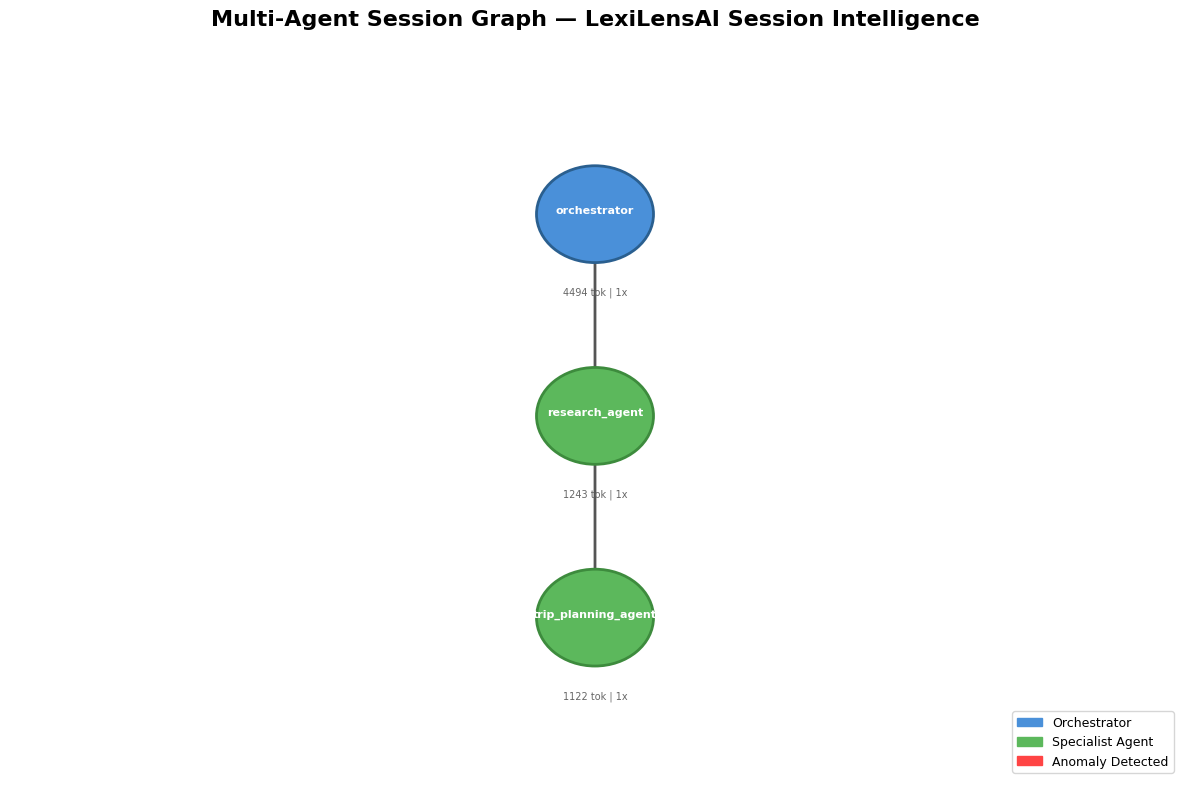


Graph saved to session_graph.png


In [29]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict

def visualize_session_graph(session, title="Agent Session Graph"):
    """
    Renders the session delegation graph using matplotlib.
    Nodes = agents, Edges = delegations, Node size = token usage.
    """
    spans = session.spans
    if not spans:
        print("No spans recorded yet.")
        return
    
    # Build graph data
    nodes = {}
    edges = []
    span_map = {s.span_id: s for s in spans}
    
    for span in spans:
        name = span.agent_name
        if name not in nodes:
            nodes[name] = {"tokens_in": 0, "tokens_out": 0, "calls": 0, "has_anomaly": False}
        nodes[name]["tokens_in"] += span.token_input or 0
        nodes[name]["tokens_out"] += span.token_output or 0
        nodes[name]["calls"] += 1
        
        if span.parent_span_id and span.parent_span_id in span_map:
            parent_name = span_map[span.parent_span_id].agent_name
            edges.append((parent_name, name))
    
    # Check anomalies
    for anomaly in session.anomalies:
        agent = anomaly.get("agent", "")
        if agent in nodes:
            nodes[agent]["has_anomaly"] = True
    
    # Layout: simple hierarchical
    levels = defaultdict(list)
    all_targets = set(e[1] for e in edges)
    all_sources = set(e[0] for e in edges)
    roots = all_sources - all_targets
    if not roots:
        roots = {spans[0].agent_name}
    
    # BFS for levels
    visited = set()
    queue = [(r, 0) for r in roots]
    while queue:
        node, level = queue.pop(0)
        if node in visited:
            continue
        visited.add(node)
        levels[level].append(node)
        for src, tgt in edges:
            if src == node and tgt not in visited:
                queue.append((tgt, level + 1))
    
    for name in nodes:
        if name not in visited:
            max_level = max(levels.keys()) + 1 if levels else 0
            levels[max_level].append(name)
    
    # Calculate positions
    positions = {}
    for level, names in levels.items():
        for i, name in enumerate(names):
            x = (i + 0.5) * (10.0 / max(len(names), 1))
            y = -level * 2.5
            positions[name] = (x, y)
    
    # Draw
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    ax.set_xlim(-1, 11)
    y_vals = [p[1] for p in positions.values()]
    ax.set_ylim(min(y_vals) - 2, max(y_vals) + 2)
    ax.axis('off')
    ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    
    # Draw edges
    drawn_edges = set()
    for src, tgt in edges:
        edge_key = (src, tgt)
        if edge_key in drawn_edges:
            continue
        drawn_edges.add(edge_key)
        if src in positions and tgt in positions:
            x1, y1 = positions[src]
            x2, y2 = positions[tgt]
            ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="->", color="#555555", lw=2))
    
    # Draw nodes
    for name, pos in positions.items():
        info = nodes.get(name, {"tokens_in": 0, "tokens_out": 0, "calls": 0, "has_anomaly": False})
        
        if info["has_anomaly"]:
            color, edge_color = "#FF4444", "#CC0000"
        elif name in roots:
            color, edge_color = "#4A90D9", "#2A5F8F"
        else:
            color, edge_color = "#5CB85C", "#3D8B3D"
        
        circle = plt.Circle(pos, 0.6, color=color, ec=edge_color, lw=2, zorder=5)
        ax.add_patch(circle)
        
        short_name = name[:20] if len(name) > 20 else name
        ax.text(pos[0], pos[1] + 0.05, short_name, ha='center', va='center',
                fontsize=8, fontweight='bold', color='white', zorder=6)
        
        token_str = f"{info['tokens_in']+info['tokens_out']} tok | {info['calls']}x"
        ax.text(pos[0], pos[1] - 0.9, token_str, ha='center', va='top',
                fontsize=7, color='#666666')
    
    # Legend
    legend_elements = [
        mpatches.Patch(color='#4A90D9', label='Orchestrator'),
        mpatches.Patch(color='#5CB85C', label='Specialist Agent'),
        mpatches.Patch(color='#FF4444', label='Anomaly Detected'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
    
    plt.tight_layout()
    plt.savefig("session_graph.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\nGraph saved to session_graph.png")


# Render the session graph from our auto-instrumented run
visualize_session_graph(lexilens.session, title="Multi-Agent Session Graph — LexiLensAI Session Intelligence")

## Anomaly Detection: Catching Silent Failures

Traditional tracing (including Strands built-in) shows "success" for every span. But LexiLensAI detects **session-level anomalies** — problems that only become visible when you look at the execution as a whole.

Let's simulate a retry storm: an agent calling itself repeatedly with the same query. Each call "succeeds." Strands telemetry sees 5 successful spans. LexiLensAI sees a pattern.

In [30]:
# Simulate a retry storm - agent called 5x with same input in rapid succession
# In production, this happens when an agent isn't satisfied with its own output
# and re-queries. Each individual call "succeeds" but the session is burning tokens.

import time

print("Simulating retry storm...\n")
print("Each call returns 'success'. Strands telemetry sees nothing wrong.")
print("LexiLensAI analyzes the SESSION pattern:\n")

for i in range(5):
    fake_span = Span(
        trace_id=lexilens.trace_id,
        span_id=str(uuid.uuid4()),
        parent_span_id=lexilens._span_stack[-1] if lexilens._span_stack else None,
        session_id=lexilens.session_id,
        agent_name="research_agent_retry_sim",
        event="agent_invocation",
        status="success",  # Each call "succeeds"!
        start_time=datetime.now(timezone.utc).isoformat(),
        end_time=datetime.now(timezone.utc).isoformat(),
        duration_ms=1200 + (i * 300),
        token_input=500,
        token_output=2000,
        metadata={"input": "What are the best hotels in Barcelona?"}  # Same query each time
    )
    lexilens.session.add_span(fake_span)
    time.sleep(0.1)  # Rapid succession

# Now check what LexiLens caught
print("=" * 50)
print("STRANDS BUILT-IN TELEMETRY SEES:")
print("  span_1: status=success, latency=1200ms")
print("  span_2: status=success, latency=1500ms")
print("  span_3: status=success, latency=1800ms")
print("  span_4: status=success, latency=2100ms")
print("  span_5: status=success, latency=2400ms")
print("  → Conclusion: everything is fine ✓")
print("=" * 50)
print()
print("LEXILENSAI SESSION INTELLIGENCE SEES:")

lexilens.report()

Simulating retry storm...

Each call returns 'success'. Strands telemetry sees nothing wrong.
LexiLensAI analyzes the SESSION pattern:

STRANDS BUILT-IN TELEMETRY SEES:
  span_1: status=success, latency=1200ms
  span_2: status=success, latency=1500ms
  span_3: status=success, latency=1800ms
  span_4: status=success, latency=2100ms
  span_5: status=success, latency=2400ms
  → Conclusion: everything is fine ✓

LEXILENSAI SESSION INTELLIGENCE SEES:

LEXILENS SESSION REPORT
Session:        1c2423f6...
Total spans:    8
Tokens:         5897 in / 13462 out
Agents used:    research_agent_retry_sim, trip_planning_agent, orchestrator, research_agent
Duration:       37763ms

Delegation Graph:
  research_agent -> trip_planning_agent
  orchestrator -> research_agent

⚠️  ANOMALIES DETECTED: 3
  [HIGH] retry_storm: Agent called 3x in <60s with similar input
  [HIGH] retry_storm: Agent called 4x in <60s with similar input
  [HIGH] retry_storm: Agent called 5x in <60s with similar input


{'session_id': '1c2423f6-39bc-4c81-9684-4fad9683cca5',
 'total_spans': 8,
 'total_tokens': {'input': 5897, 'output': 13462},
 'unique_agents': ['research_agent_retry_sim',
  'trip_planning_agent',
  'orchestrator',
  'research_agent'],
 'delegation_graph': {'research_agent': ['trip_planning_agent'],
  'orchestrator': ['research_agent']},
 'anomalies': [{'type': 'retry_storm',
   'severity': 'high',
   'agent': 'research_agent_retry_sim',
   'detail': 'Agent called 3x in <60s with similar input',
   'timestamp': '2026-07-21T12:16:44.527848+00:00'},
  {'type': 'retry_storm',
   'severity': 'high',
   'agent': 'research_agent_retry_sim',
   'detail': 'Agent called 4x in <60s with similar input',
   'timestamp': '2026-07-21T12:16:44.629259+00:00'},
  {'type': 'retry_storm',
   'severity': 'high',
   'agent': 'research_agent_retry_sim',
   'detail': 'Agent called 5x in <60s with similar input',
   'timestamp': '2026-07-21T12:16:44.732560+00:00'}],
 'duration_ms': 37763.218}

## Key Insight: Three Levels of Observability

| Aspect | Manual emit_span() | Strands Built-in | LexiLensAI |
|--------|:------------------:|:----------------:|:----------:|
| Code overhead | 50+ lines per tool | 1 setup call | 1 setup call |
| What you get | Custom spans | Flat OTel spans | Session graphs |
| Delegation tracking | Manual parent_span_id | ❌ | ✓ Automatic |
| Session awareness | ❌ | ❌ | ✓ Full graph |
| Anomaly detection | ❌ | ❌ | ✓ Real-time |
| Cost attribution | Per-span (manual) | Per-span (auto) | Per-session + per-agent |
| Timeline replay | ❌ | ❌ | ✓ Session reconstruction |
| Works with | Custom code | Strands only | Any OTel source |
| Governance | ❌ | ❌ | ✓ Policy evaluation |

**The progression:**
1. **Manual** → You see what you remembered to instrument
2. **Strands telemetry** → You see every span automatically  
3. **LexiLensAI** → You understand what the session DID and WHY

**Spans answer:** *What happened?*  
**Sessions answer:** *Why did it happen? What went wrong? How do I fix it?*

---

## Architecture: How The Pieces Fit

```
┌─────────────────────────────────────────────────────────────┐
│  Your Multi-Agent Application (Strands, LangChain, etc.)    │
└──────────────────────┬──────────────────────────────────────┘
                       │
            ┌──────────┴──────────┐
            │                     │
            ▼                     ▼
┌───────────────────┐   ┌────────────────────────┐
│ Strands Telemetry │   │ LexiLens SDK           │
│ (Span-level)      │   │ (Session-level)        │
│ • Agent names     │   │ • Delegation graphs    │
│ • Tool calls      │   │ • Parent-child links   │
│ • Token counts    │   │ • Anomaly detection    │
│ • Latency         │   │ • Session cost         │
│ • Errors          │   │ • Execution lineage    │
└────────┬──────────┘   └──────────┬─────────────┘
         │                         │
         ▼                         ▼
┌───────────────────┐   ┌────────────────────────┐
│ OTel Collector    │   │ Session Store          │
│ (X-Ray/Jaeger/    │   │ (JSONL → PostgreSQL →  │
│  Tempo/Datadog)   │   │  agent-session-graph)  │
└───────────────────┘   └──────────┬─────────────┘
                                   │
                                   ▼
                        ┌────────────────────────┐
                        │ LexiLensAI Platform    │
                        │ • Session replay       │
                        │ • Governance engine    │
                        │ • Root cause analysis  │
                        │ • Cost attribution     │
                        │ • Multi-session trends │
                        └────────────────────────┘
```

**Strands telemetry and LexiLensAI are complementary, not competing.**

Strands gives you the raw spans. LexiLensAI reconstructs them into sessions and tells you what went wrong.

---

*Built by CurvSort | [github.com/curvsort/agent-session-graph](https://github.com/curvsort/agent-session-graph) | [curvsort.com/lexilensai](https://www.curvsort.com/lexilensai)*